<a href="https://colab.research.google.com/github/xysu129/deep-learning-ust-2026/blob/main/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kagglehub
import kagglehub
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6108b40e8f2d8d7ff5d44af9eb1cc264'

print("正在下载并解压 CelebA 数据集")
dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"数据集已准备好，路径为: {dataset_path}")

# Read Attribute Tag Table
attr_csv_path = os.path.join(dataset_path, 'list_attr_celeba.csv')
attr_df = pd.read_csv(attr_csv_path)

# To reduce the data volume, we randomly sampled 10,000 images
subset_df = attr_df.sample(n=10000, random_state=42).copy()

img_dir = os.path.join(dataset_path, 'img_align_celeba', 'img_align_celeba')
if not os.path.exists(img_dir):
    # If it is not nested two levels deep, use a single-level path as an alternative.
    img_dir = os.path.join(dataset_path, 'img_align_celeba')

subset_df['image_path'] = img_dir + '/' + subset_df['image_id']

# Building Data Pipelines using tf.data.Dataset
# Resize images to 64x64
IMG_SIZE = 64
BATCH_SIZE = 64

def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0  # Normalize to the [0, 1] range
    return img

image_paths = subset_df['image_path'].values
dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# shape验证
for batch in dataset.take(1):
    print("Batch shape:", batch.shape)

正在下载并解压 CelebA 数据集，这可能需要几分钟...
Using Colab cache for faster access to the 'celeba-dataset' dataset.
数据集已准备好，路径为: /kaggle/input/celeba-dataset
Batch shape: (64, 64, 64, 3)


In [3]:
import keras
from keras import layers

# Adjusting Latent Space Dimensions
latent_dim = 128

# Encoder
inputs = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inputs)    # 输出: 32x32x32
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)         # 输出: 16x16x64
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)        # 输出: 8x8x128
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Reparameterization
def sample_z(args):
    z_mean, z_log_var = args
    eps = keras.random.normal(shape=keras.ops.shape(z_mean))
    return z_mean + keras.ops.exp(0.5 * z_log_var) * eps

z = layers.Lambda(sample_z)([z_mean, z_log_var])
encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
print("=== Encoder Summary ===")
encoder.summary()

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
# Restore the dimensions prior to the Encoder Flatten layer: 8 * 8 * 128 = 8192
x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)
# Gradual Dimensional Expansion: 8 -> 16 -> 32 -> 64
x = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
# Finally, output the three RGB channels, using a sigmoid function to constrain the pixel values ​​to the range [0, 1]
outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, outputs, name="decoder")
print("\n=== Decoder Summary ===")
decoder.summary()

# Define VAE Model
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed_inputs = self.decoder(z)

        # Reconstruction Loss
        recon_loss = keras.ops.mean(
            keras.losses.binary_crossentropy(inputs, reconstructed_inputs)
        )
        recon_loss *= 64 * 64 * 3  # Change to the new total number of image pixels

        # Calculate KL Divergence Loss
        kl_loss = -0.5 * keras.ops.mean(
            1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var)
        )

        beta = 0.001
        self.add_loss(recon_loss + beta * kl_loss)

        return reconstructed_inputs

# Instantiate and compile the model
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

# Keras's `.fit()` method expects the `(x, y)` format by default.
# We therefore need to convert the `(image)` input into an `(image, image)` tuple to "trick" Keras into performing the computation correctly.
dataset_train = dataset.map(lambda x: (x, x))

=== Encoder Summary ===


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  1,048,704 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,174,976 (4.48 MB)

 Trainable params: 1,174,976 (4.48 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297,475 (4.95 MB)

 Trainable params: 1,297,475 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Set epochs to 20 as shown in the lecture slides
EPOCHS = 20

# We use the dataset_train we prepared earlier
print(f"Starting training for {EPOCHS} epochs...")
history = vae.fit(
    dataset_train,
    epochs=EPOCHS
)
print("Training completed!")

Starting training for 20 epochs...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 267ms/step - loss: 7356.9385
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 6604.5225
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 6470.2866
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 6381.5088
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 6329.1538
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 6308.4316
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 6277.6226
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 6255.3354
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 6240.5967
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 6240.1670
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 6234.1006
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 6225.3330
Epoch 13/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 6221.0093
Epoch 14/20
157/157 ━━━━━━━━━━━━━━━━

Loading images into RAM for arithmetic...
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


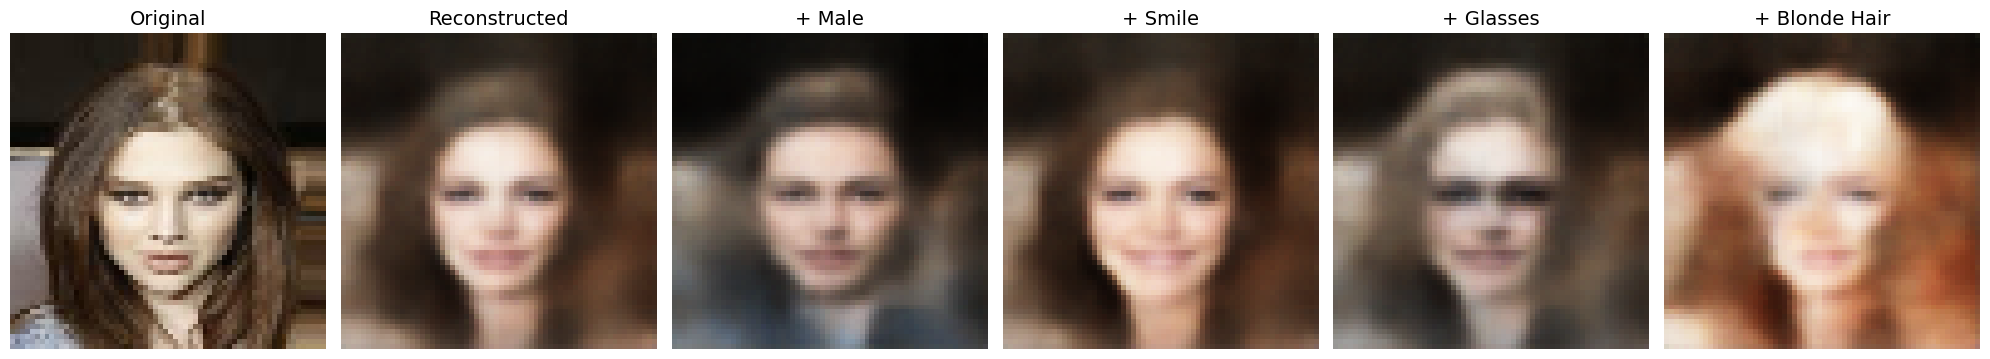

In [6]:
# Attempt 1:
# Latent Space Arithmetic
import numpy as np

# Load all subset images into RAM (approx. 500MB, easily fits in Colab)
print("Loading images into RAM for arithmetic...")
all_images = np.array([load_and_preprocess_image(p) for p in subset_df['image_path']])

# Get the latent representations (z_mean) for all 10,000 images
# We use z_mean instead of z because we want the deterministic center of the distribution
z_mean_all, _, _ = encoder.predict(all_images, batch_size=BATCH_SIZE)

# 3. Define a helper function to calculate the attribute vector
def get_attribute_vector(z_means, pos_condition, neg_condition):
    # Calculate the mean latent vector for positive and negative samples
    z_pos_mean = np.mean(z_means[pos_condition], axis=0)
    z_neg_mean = np.mean(z_means[neg_condition], axis=0)
    # The direction vector points from negative to positive
    return z_pos_mean - z_neg_mean

# Calculate vectors for the 4 attributes requested
# CelebA uses 1 for presence and -1 for absence of an attribute
vec_male = get_attribute_vector(
    z_mean_all,
    subset_df['Male'] == 1,
    subset_df['Male'] == -1
)

vec_smile = get_attribute_vector(
    z_mean_all,
    subset_df['Smiling'] == 1,
    subset_df['Smiling'] == -1
)

vec_glasses = get_attribute_vector(
    z_mean_all,
    subset_df['Eyeglasses'] == 1,
    subset_df['Eyeglasses'] == -1
)

# Note: Black_Hair and Blond_Hair are separate columns in CelebA
vec_blonde = get_attribute_vector(
    z_mean_all,
    subset_df['Blond_Hair'] == 1,
    subset_df['Black_Hair'] == 1
)

# Apply the vectors to a random test image
# Pick a random image index from our subset
test_idx = 42
test_img = all_images[test_idx]
test_z = z_mean_all[test_idx:test_idx+1] # Keep dimensions as (1, latent_dim)

# Define a scale factor to amplify the effect
scale = 2.0

# Apply arithmetic in latent space
z_mod_male = test_z + scale * vec_male
z_mod_smile = test_z + scale * vec_smile
z_mod_glasses = test_z + scale * vec_glasses
z_mod_blonde = test_z + scale * vec_blonde

# Decode the modified vectors back into images
# decoder.predict expects shape (batch_size, latent_dim)
img_recon = decoder.predict(test_z, verbose=0)[0]
img_male = decoder.predict(z_mod_male, verbose=0)[0]
img_smile = decoder.predict(z_mod_smile, verbose=0)[0]
img_glasses = decoder.predict(z_mod_glasses, verbose=0)[0]
img_blonde = decoder.predict(z_mod_blonde, verbose=0)[0]

# Plot the results
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

# List of images and titles for dynamic plotting
plot_data = [
    (test_img, "Original"),
    (img_recon, "Reconstructed"),
    (img_male, "+ Male"),
    (img_smile, "+ Smile"),
    (img_glasses, "+ Glasses"),
    (img_blonde, "+ Blonde Hair")
]

for ax, (img, title) in zip(axes, plot_data):
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

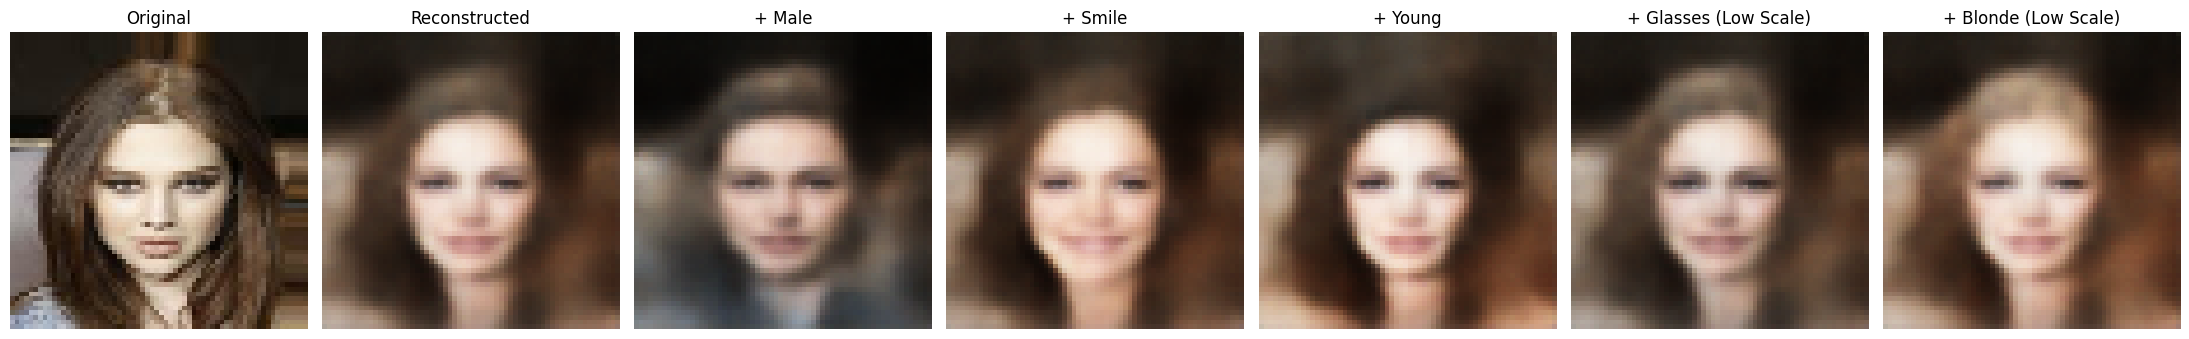

In [7]:
# Attempt 2:
# Updated Latent Space Arithmetic
import numpy as np
import matplotlib.pyplot as plt

# We already have z_mean_all from the previous run
# test_idx and test_z are also still in memory

# Add the "Young" attribute as recommended by the professor
vec_young = get_attribute_vector(
    z_mean_all,
    subset_df['Young'] == 1,
    subset_df['Young'] == -1
)

# Use individual scales to prevent image distortion
# Global features can handle higher scales (1.5 - 2.0)
scale_male = 1.8
scale_smile = 1.8
scale_young = 1.8

# Subtle/noisy features need much lower scales to avoid artifacting
scale_glasses = 0.8
scale_blonde = 0.6

# Apply arithmetic with individual scales
z_mod_male = test_z + scale_male * vec_male
z_mod_smile = test_z + scale_smile * vec_smile
z_mod_young = test_z + scale_young * vec_young
z_mod_glasses = test_z + scale_glasses * vec_glasses
z_mod_blonde = test_z + scale_blonde * vec_blonde

# Decode
img_recon = decoder.predict(test_z, verbose=0)[0]
img_male = decoder.predict(z_mod_male, verbose=0)[0]
img_smile = decoder.predict(z_mod_smile, verbose=0)[0]
img_young = decoder.predict(z_mod_young, verbose=0)[0]
img_glasses = decoder.predict(z_mod_glasses, verbose=0)[0]
img_blonde = decoder.predict(z_mod_blonde, verbose=0)[0]

# Plot the updated results
fig, axes = plt.subplots(1, 7, figsize=(22, 4))

plot_data = [
    (test_img, "Original"),
    (img_recon, "Reconstructed"),
    (img_male, "+ Male"),
    (img_smile, "+ Smile"),
    (img_young, "+ Young"),           # Added the reliable attribute
    (img_glasses, "+ Glasses (Low Scale)"),
    (img_blonde, "+ Blonde (Low Scale)")
]

for ax, (img, title) in zip(axes, plot_data):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()